# Lesson 2 : LangGraph Components

In [3]:
from dotenv import load_dotenv
_ = load_dotenv()

In [4]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

In [5]:
tool = TavilySearchResults(max_results=4) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


> If you are not familiar with python typing annotation, you can refer to the [python documents](https://docs.python.org/3/library/typing.html).

In [6]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

> Note: in `take_action` below, some logic was added to cover the case that the LLM returned a non-existent tool name. Even with function calling, LLMs can still occasionally hallucinate. Note that all that is done is instructing the LLM to try again! An advantage of an agentic organization.

In [7]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [11]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model="gpt-3.5-turbo")  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

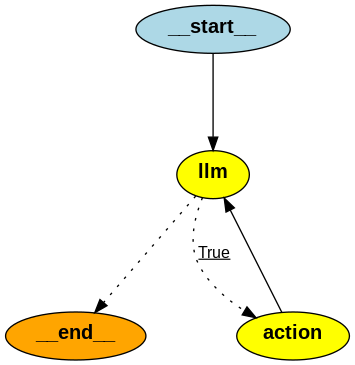

In [12]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

In [13]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_PvPN1v7bHUxOdyn4J2xJhYOX'}
Back to the model!


In [14]:
result

{'messages': [HumanMessage(content='What is the weather in sf?'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_PvPN1v7bHUxOdyn4J2xJhYOX', 'function': {'arguments': '{"query":"weather in San Francisco"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 153, 'total_tokens': 174, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'model_name': 'gpt-3.5-turbo', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-55b718e9-28c8-4a12-a62e-631ae2a95da9-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_PvPN1v7bHUxOdyn4J2xJhYOX'}]),
  ToolMessage(content='[{\'url\': \'https://www.weather25.com/north-america/usa/california/san-franci

In [15]:
result['messages'][-1].content

"The weather in San Francisco in January is quite cold with temperatures ranging between 7°C and 15°C. There are about 3 to 8 days of rain expected during the month, so it's a good idea to carry an umbrella. The weather forecast includes clear days, partly cloudy days, and some mist and overcast conditions."

In [19]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_3AAaDSfchif60Drx9QyyOiZS'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_Ldw8ZaATItg9oW0SRBlhKtpc'}
Back to the model!


In [20]:
result

{'messages': [HumanMessage(content='What is the weather in SF and LA?'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_3AAaDSfchif60Drx9QyyOiZS', 'function': {'arguments': '{"query": "weather in San Francisco"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_Ldw8ZaATItg9oW0SRBlhKtpc', 'function': {'arguments': '{"query": "weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 155, 'total_tokens': 212, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'model_name': 'gpt-3.5-turbo', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-78457f3a-cce7-4008-9356-93c2bdfdd2e5-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query':

In [21]:
result['messages'][-1].content

'The weather in San Francisco for January 2026 is quite cold with temperatures ranging between 7°C and 15°C. There are about 3 to 8 days of rain expected during the month. The weather forecast indicates a mix of clear, mist, partly cloudy, and sunny days.\n\nIn Los Angeles, the temperatures in January are comfortable with a low of 11°C and a high of 21°C. Similar to San Francisco, there are about 3 to 8 days of rain expected. The weather forecast for Los Angeles includes a mix of temperatures and mostly clear days.\n\nIf you need more specific details or forecasts for a particular day, feel free to let me know!'

In [22]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model="gpt-4o")  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': '2024 Super Bowl winner'}, 'id': 'call_HBUU1Lo9WSgKCPKYCAStSb7g'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_G09rhVCH0l4O4P49HwmDMKZg'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Missouri GDP 2024'}, 'id': 'call_ZSvkiNGFbRvRk5p1iwSXn5rv'}
Back to the model!


In [23]:
print(result['messages'][-1].content)

1. **Who won the Super Bowl in 2024?**
   - The Kansas City Chiefs won the Super Bowl in 2024, defeating the San Francisco 49ers in overtime with a score of 25-22.

2. **In what state is the winning team headquarters located?**
   - The Kansas City Chiefs' headquarters is located in Kansas City, Missouri.

3. **What is the GDP of that state?**
   - In 2024, Missouri's gross domestic product (GDP) was approximately $353.31 billion in inflation-adjusted (chained 2017) dollars.
